# STEP 1: Vocabulary

In [222]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

sentence = "I like orange juice and eat eggs daily"
tokens = sentence.split()

vocabulary = list(dict.fromkeys(tokens))
V = len(vocabulary)
N = 3

word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for i, word in enumerate(vocabulary)}

print("Vocabulary:", vocabulary)
print("V =", V, "N =", N)

Vocabulary: ['I', 'like', 'orange', 'juice', 'and', 'eat', 'eggs', 'daily']
V = 8 N = 3


# STEP 2: Generate Skip-Gram Training Data

In [223]:
def get_context(tokens, index, window_size=2):
    start = max(0, index - window_size)
    end = min(len(tokens), index + window_size + 1)
    return [tokens[i] for i in range(start, end) if i != index]

training_data = []

for i, word in enumerate(tokens):
    context_words = get_context(tokens, i)
    for context_word in context_words:
        training_data.append((word, context_word))

print("Training pairs:")
for pair in training_data:
    print(pair)

Training pairs:
('I', 'like')
('I', 'orange')
('like', 'I')
('like', 'orange')
('like', 'juice')
('orange', 'I')
('orange', 'like')
('orange', 'juice')
('orange', 'and')
('juice', 'like')
('juice', 'orange')
('juice', 'and')
('juice', 'eat')
('and', 'orange')
('and', 'juice')
('and', 'eat')
('and', 'eggs')
('eat', 'juice')
('eat', 'and')
('eat', 'eggs')
('eat', 'daily')
('eggs', 'and')
('eggs', 'eat')
('eggs', 'daily')
('daily', 'eat')
('daily', 'eggs')


# STEP 3: One-hot Encoding

In [224]:
def one_hot(word):
    vec = np.zeros(V)
    vec[word_to_index[word]] = 1
    return vec

# STEP 4: Initialise Weights

In [225]:
global W, W_prime
W = np.random.randn(V, N) * 0.01
W_prime = np.random.randn(N, V) * 0.01

W_initial = W.copy()
W_prime_initial = W_prime.copy()

print("W:\n", W)
print()
print("W_prime:\n", W_prime)

W:
 [[-0.0114  0.0051 -0.0056]
 [-0.0086  0.0103 -0.0179]
 [ 0.001   0.0099 -0.0234]
 [ 0.0091  0.0042  0.0084]
 [ 0.0103 -0.0134  0.0047]
 [-0.012  -0.0049 -0.0012]
 [ 0.0099 -0.0001  0.0103]
 [ 0.0092  0.0108 -0.0045]]

W_prime:
 [[ 0.0059  0.0037 -0.006   0.0079 -0.0056  0.0075 -0.0004  0.0037]
 [ 0.0051 -0.0008  0.0037 -0.003  -0.0066  0.0291  0.007  -0.0106]
 [ 0.0078  0.0056  0.0041  0.0041 -0.011   0.0145 -0.0088  0.0053]]


# STEP 5: Softmax function

In [226]:
def softmax(x):
    shifted = x - np.max(x)          # numerical stability
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x)

# STEP 6: Forward pass for one training pair

In [227]:
def forward(target, context, W, W_prime):
    x = one_hot(target)                              # shape = (V,)
    h = x @ W                                        # shape = (N,)
    u = h @ W_prime                                  # shape = (V,)
    y_pred = softmax(u)                              # shape = (V,)

    loss = -np.log(y_pred[word_to_index[context]] + 1e-12)

    cache = {
        "target": target,
        "context": context,
        "x": x,
        "h": h,
        "u": u,
        "y_pred": y_pred
    }

    return loss, cache

# STEP 7: Backpropagation for one training pair

In [228]:
def backward(cache, W, W_prime, learning_rate=0.05):
    target = cache["target"]
    context = cache["context"]
    x = cache["x"]
    h = cache["h"]
    y_pred = cache["y_pred"]

    y_true = np.zeros(V)
    y_true[word_to_index[context]] = 1.0

    error = y_pred - y_true                          # shape = (V,)

    dW_prime = np.outer(h, error)                    # shape = (N, V)
    d_hidden = W_prime @ error                       # shape = (N,)
    dW = np.outer(x, d_hidden)                       # shape = (V, N)

    W -= learning_rate * dW
    W_prime -= learning_rate * dW_prime

    return W, W_prime

# STEP 8: Training loop

In [229]:
learning_rate = 0.05
epochs = 500
loss_history = []

print("STEP 8: Training Starts")

for epoch in range(1, epochs + 1):
    total_loss = 0.0

    for target, context in training_data:
        loss, cache = forward(target, context, W, W_prime)
        total_loss += loss

        W, W_prime = backward(cache, W, W_prime, learning_rate=learning_rate)

    avg_loss = total_loss / len(training_data)
    loss_history.append(avg_loss)

    if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
        print(f"Epoch {epoch:>3} | Average Loss = {avg_loss:.6f}")

STEP 8: Training Starts
Epoch   1 | Average Loss = 2.079446
Epoch  50 | Average Loss = 1.897287
Epoch 100 | Average Loss = 1.447972
Epoch 150 | Average Loss = 1.420117
Epoch 200 | Average Loss = 1.424446
Epoch 250 | Average Loss = 1.427451
Epoch 300 | Average Loss = 1.428711
Epoch 350 | Average Loss = 1.429258
Epoch 400 | Average Loss = 1.429539
Epoch 450 | Average Loss = 1.429713
Epoch 500 | Average Loss = 1.429839


# STEP 9: Plot training loss

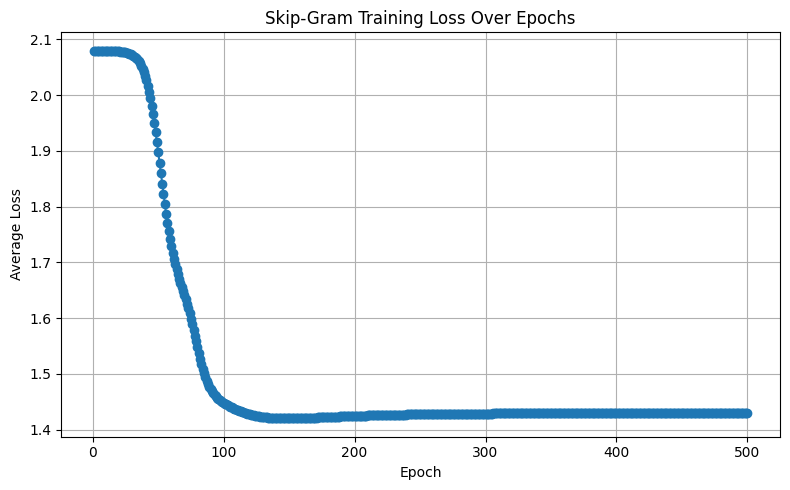

In [230]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Skip-Gram Training Loss Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 10: Show learned embeddings

In [231]:
print("STEP 10: Learned Embeddings (W)")
embedding_df = pd.DataFrame(W, index=vocabulary, columns=[f"e{i+1}" for i in range(N)])
print(embedding_df)

STEP 10: Learned Embeddings (W)
              e1        e2        e3
I      -2.240127  1.414399  0.327151
like    0.141441  1.557083 -1.522722
orange -0.833032 -1.064443 -1.398920
juice  -1.326417  0.411939  1.597749
and     1.562084  1.437888 -0.120405
eat     0.680484 -1.822741 -0.530498
eggs   -0.201396 -0.850822  2.103462
daily   2.409659  0.824316  0.947354


# STEP 11: Test one training example after learning

In [232]:
# STEP 11: Test One Target Word After Training

target_word = "juice"
target_index = [i for i, w in enumerate(tokens) if w == target_word][0]
context_words = get_context(tokens, target_index, window_size=2)

x = one_hot(target_word)
h = x @ W
u = h @ W_prime
y_pred = softmax(u)

result_df = pd.DataFrame({
    "Word": vocabulary,
    "Score": u,
    "Probability": y_pred,
    "Is_Actual_Context": [word in context_words for word in vocabulary]
}).sort_values(by="Probability", ascending=False).reset_index(drop=True)

context_prob_sum = sum(y_pred[word_to_index[w]] for w in context_words)

top_k = result_df.head(len(context_words))["Word"].tolist()

print("STEP 11: Test One Target Word After Training")
print("Target word           :", target_word)
print("Actual context words  :", context_words)
print("Top-k predictions     :", top_k)
print("Context probability sum:", context_prob_sum)
print()

print(result_df)

STEP 11: Test One Target Word After Training
Target word           : juice
Actual context words  : ['like', 'orange', 'and', 'eat']
Top-k predictions     : ['eat', 'orange', 'and', 'like']
Context probability sum: 0.9565104252707752

     Word     Score  Probability  Is_Actual_Context
0     eat  2.410988     0.299742               True
1  orange  2.109274     0.221674               True
2     and  2.096362     0.218831               True
3    like  2.084562     0.216263               True
4   daily  0.258206     0.034818              False
5       I -1.430292     0.006434              False
6    eggs -2.577705     0.002043              False
7   juice -4.929717     0.000194              False


The Skip-Gram model learns a probability distribution over the vocabulary such that the true context words of a target word receive the highest probabilities. Rather than predicting a single neighbouring word, the model captures the entire contextual neighbourhood as a structured distribution, demonstrating that the learned embeddings encode meaningful relationships between words.

<b>Meaning in Skip-Gram is not a prediction—it is a distribution.</b>

# STEP 12: Show all training pairs with predictions

In [233]:
print("STEP 12: Final Evaluation for All Target Words (Pretty Table)")

from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Target", "Context Words", "Top-k Predictions", "Context Prob Sum"]

# Evaluate per target word (NOT per pair)
unique_targets = list(dict.fromkeys(tokens))

for target in unique_targets:
    target_index = [i for i, w in enumerate(tokens) if w == target][0]
    context_words = get_context(tokens, target_index, window_size=2)

    x = one_hot(target)
    h = x @ W
    u = h @ W_prime
    y_pred = softmax(u)

    # Total probability mass on actual context
    context_prob_sum = sum(y_pred[word_to_index[w]] for w in context_words)

    # Top-k predictions
    k = len(context_words)
    top_k = [index_to_word[i] for i in np.argsort(-y_pred)[:k]]

    table.add_row([
        target,
        ", ".join(context_words),
        ", ".join(top_k),
        round(context_prob_sum, 4)
    ])

print(table)

STEP 12: Final Evaluation for All Target Words (Pretty Table)
+--------+--------------------------+--------------------------+------------------+
| Target |      Context Words       |    Top-k Predictions     | Context Prob Sum |
+--------+--------------------------+--------------------------+------------------+
|   I    |       like, orange       |       orange, like       |      0.9652      |
|  like  |     I, orange, juice     |     juice, orange, I     |      0.9707      |
| orange |   I, like, juice, and    |   and, like, I, juice    |      0.9756      |
| juice  |  like, orange, and, eat  |  eat, orange, and, like  |      0.9565      |
|  and   | orange, juice, eat, eggs | eggs, eat, juice, orange |      0.9617      |
|  eat   | juice, and, eggs, daily  | daily, eggs, and, juice  |      0.9731      |
|  eggs  |     and, eat, daily      |     daily, eat, and      |      0.9689      |
| daily  |        eat, eggs         |        eggs, eat         |      0.9623      |
+--------+----

The final evaluation confirms that the Skip-Gram model has learned the contextual structure of the sentence remarkably well. For each target word, the top predicted words closely match the actual context words within the chosen window. More importantly, the total probability mass assigned to the true context words is consistently very high, exceeding 95% in every case. This demonstrates that the model is not merely selecting a single neighbouring word, but learning a full probability distribution in which the correct context words dominate. In this sense, the learned embedding space has successfully captured the local co-occurrence patterns of the corpus.

<b>Skip-Gram is best understood not as a model that predicts one neighbouring word, but as a model that concentrates probability mass on the set of true neighbouring words.</b>

# STEP 13: Final embedding lookup example

In [234]:
print("STEP 13: Final Embedding of the Target Word")
print(f"Embedding for '{target_word}' =", W[word_to_index[target_word]])

STEP 13: Final Embedding of the Target Word
Embedding for 'juice' = [-1.3264  0.4119  1.5977]


# STEP 14: Compare Before vs After Training for One Target Word

STEP 14: Before vs After Training for One Target Word
Target word: juice
Actual context words: ['like', 'orange', 'and', 'eat']

BEFORE TRAINING
     Word  Probability_Before  Is_Actual_Context
0     eat            0.125032               True
1       I            0.125011              False
2   juice            0.125005              False
3    like            0.125003               True
4   daily            0.124997              False
5  orange            0.124993               True
6    eggs            0.124987              False
7     and            0.124972               True

Total probability assigned to actual context words (before) = 0.4999996609749139

AFTER TRAINING
     Word  Probability_After  Is_Actual_Context
0     eat           0.299742               True
1  orange           0.221674               True
2     and           0.218831               True
3    like           0.216263               True
4   daily           0.034818              False
5       I           0.006434

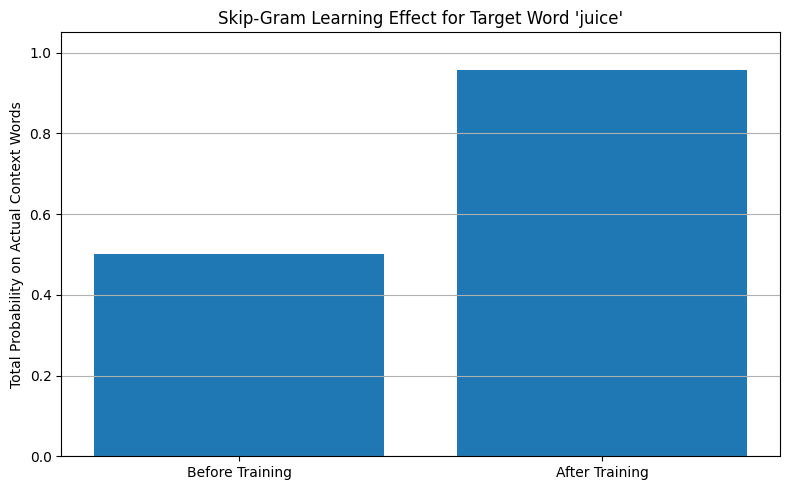

In [237]:
target_word = "juice"
target_index = [i for i, w in enumerate(tokens) if w == target_word][0]
context_words = get_context(tokens, target_index, window_size=2)

print("STEP 14: Before vs After Training for One Target Word")
print("Target word:", target_word)
print("Actual context words:", context_words)
print()

# ------------------------------------------------------------
# Forward pass BEFORE training
# ------------------------------------------------------------
x_before = one_hot(target_word)
h_before = x_before @ W_initial
u_before = h_before @ W_prime_initial
y_pred_before = softmax(u_before)

before_df = pd.DataFrame({
    "Word": vocabulary,
    "Probability_Before": y_pred_before,
    "Is_Actual_Context": [word in context_words for word in vocabulary]
}).sort_values(by="Probability_Before", ascending=False).reset_index(drop=True)

context_prob_sum_before = sum(y_pred_before[word_to_index[w]] for w in context_words)

print("BEFORE TRAINING")
print(before_df)
print("\nTotal probability assigned to actual context words (before) =", context_prob_sum_before)

# ------------------------------------------------------------
# Forward pass AFTER training
# ------------------------------------------------------------
x_after = one_hot(target_word)
h_after = x_after @ W
u_after = h_after @ W_prime
y_pred_after = softmax(u_after)

after_df = pd.DataFrame({
    "Word": vocabulary,
    "Probability_After": y_pred_after,
    "Is_Actual_Context": [word in context_words for word in vocabulary]
}).sort_values(by="Probability_After", ascending=False).reset_index(drop=True)

context_prob_sum_after = sum(y_pred_after[word_to_index[w]] for w in context_words)

print("\nAFTER TRAINING")
print(after_df)
print("\nTotal probability assigned to actual context words (after) =", context_prob_sum_after)

# ------------------------------------------------------------
# Side-by-side comparison
# ------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Word": vocabulary,
    "Probability_Before": y_pred_before,
    "Probability_After": y_pred_after,
    "Change": y_pred_after - y_pred_before,
    "Is_Actual_Context": [word in context_words for word in vocabulary]
}).sort_values(by="Probability_After", ascending=False).reset_index(drop=True)

print("\nSIDE-BY-SIDE COMPARISON")
print(comparison_df)

# ------------------------------------------------------------
# Top-k comparison
# ------------------------------------------------------------
k = len(context_words)

top_before = before_df.head(k)["Word"].tolist()
top_after = after_df.head(k)["Word"].tolist()

print("\nTop", k, "predicted words before training:", top_before)
print("Top", k, "predicted words after training :", top_after)

# ------------------------------------------------------------
# Visual comparison: probability mass before vs after
# ------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(["Before Training", "After Training"],
        [context_prob_sum_before, context_prob_sum_after])
plt.ylabel("Total Probability on Actual Context Words")
plt.title(f"Skip-Gram Learning Effect for Target Word '{target_word}'")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

The result clearly demonstrates the learning effect of the Skip-Gram model. Before training, the model assigns nearly uniform probabilities across all words, with each word receiving approximately 0.125, reflecting the randomness of the initial weight matrices. Consequently, only about 50% of the total probability mass is incidentally assigned to the true context words of “juice.” After training, however, the distribution becomes highly structured: the actual context words—“eat,” “orange,” “and,” and “like”—emerge as the top predictions and collectively receive over 95% of the total probability mass. At the same time, non-context words are strongly suppressed. This shift illustrates that the model has successfully learned the contextual relationships of the target word, transforming an initially uniform distribution into one that concentrates probability on meaningful neighbours. In essence, the embedding for “juice” has evolved from a random vector into a representation that encodes its true linguistic context.

# Step 15: Embedding Similarity

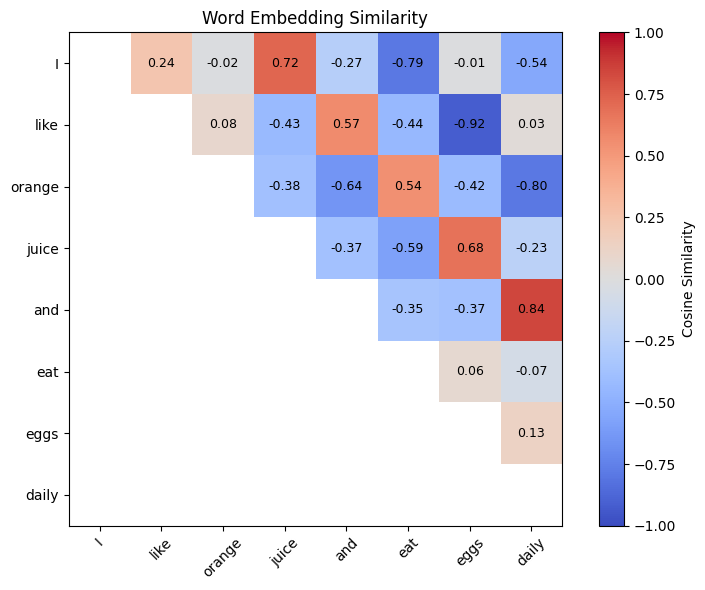

In [236]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity
sim = cosine_similarity(W)

# Create mask (hide lower triangle)
mask = np.tril(np.ones_like(sim, dtype=bool))

# Apply mask
sim_masked = np.ma.masked_where(mask, sim)

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(sim_masked, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(label="Cosine Similarity")

plt.xticks(ticks=np.arange(len(vocabulary)), labels=vocabulary, rotation=45)
plt.yticks(ticks=np.arange(len(vocabulary)), labels=vocabulary)

for i in range(len(vocabulary)):
    for j in range(len(vocabulary)):
        if not mask[i, j]:
            plt.text(j, i, f"{sim[i, j]:.2f}",
                     ha='center', va='center', fontsize=9)

plt.title("Word Embedding Similarity")
plt.tight_layout()
plt.show()

This visualization reveals the geometric structure of the learned word embeddings by showing the pairwise cosine similarity between words. Since cosine similarity measures how aligned two vectors are, values close to +1 indicate strong similarity (words appearing in similar contexts), while values close to -1 indicate strong dissimilarity.

Several meaningful patterns emerge from the plot. Words that share contextual roles exhibit high similarity—for instance, <b>juice</b> shows strong similarity with <b>I</b> (0.72) and <b>eggs</b> (0.68), reflecting their co-occurrence patterns in the sentence. Similarly, <b>and</b> and <b>daily</b> exhibit a strong positive relationship (0.84), suggesting that the model has captured their positional or contextual proximity. Conversely, strong negative similarities, such as between <b>like</b> and <b>eggs</b> (-0.92) or <b>I</b> and <b>eat</b> (-0.79), indicate that these words rarely share similar contexts in the training data. Overall, this matrix demonstrates that the embeddings have organized words into a meaningful vector space where relationships are encoded not as explicit rules, but as distances and directions—providing a powerful geometric interpretation of language learned through the Skip-Gram model.